In [20]:
import numpy as np
import random
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
from scipy.optimize import curve_fit
import warnings

Pm = 907 /8 * 1e3 # коэффициент перевода из пкс в м

warnings.filterwarnings("ignore")

In [132]:
x_lims1 = [[0, 150], [0, 150], [25, 150],
          [0, 150], [-100, 50], [-100, 100],
          [-100, 100], [-100, 50], [-100, 100]]
x_lims2 = [[0, 150], [50, 200], [-100, 150],
          [-100, 100], [-50, 100], [-100, 100],
          [-100, 100], [-100, 100], [-100, 100]]
x_lims3 = [[-100, 100], [50, 150], [-100, 100],
          [-100, 100], [-100, 100], [-100, 100],
          [50, 150], [-100, 100], [-100, 100]]
x_lims4 = [[-50, 150], [100, 200], [-100, 100],
          [-100, 100], [-100, 150], [-50, 150],
          [50, 150], [-100, 100], [-100, 100]]
x_lims5 = [[-300, 150], [-300, 100], [-200, 100],
          [-150, 150], [-300, 100], [-300, 100],
          [-300, 100], [-300, 100], [-300, 100]]

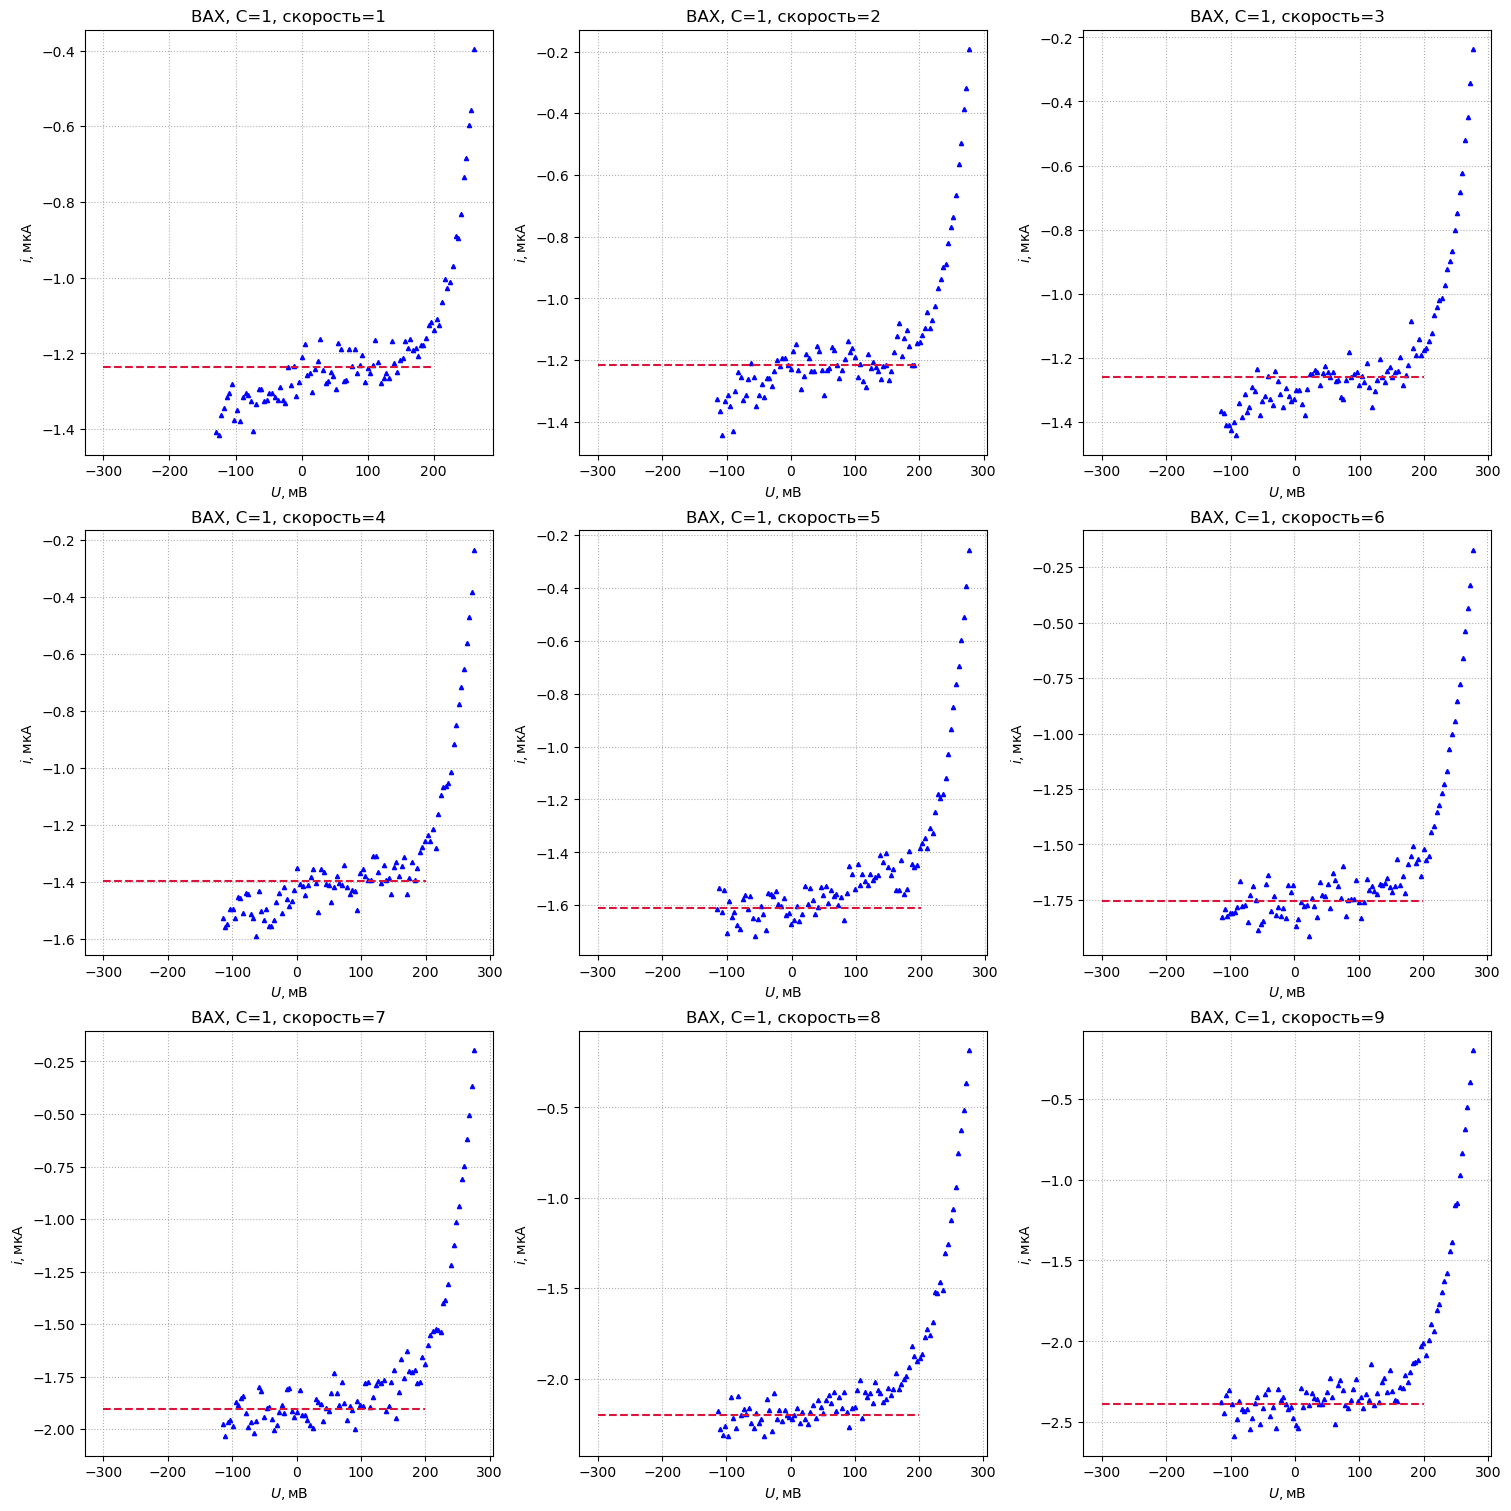

In [172]:
time = []
I = []
U = []
bord = []
for i in range(1, 10):
    path = "electro_2/c1/speed_{}.txt".format(i)
    with open(path, encoding="latin-1") as f:
        lines = f.readlines()[7:]
        i = []
        u = []
        for line in lines:
            mnt = list(map(float, line.strip().split()))
            u.append(mnt[1])
            i.append(mnt[2])
        # i = np.array(i)
        # u = np.array(u)
        I.append(i)
        U.append(u)

i_lim = []
fig, axs = plt.subplots(3, 3, figsize=(15, 15), layout='constrained')
for ax, idx in zip(axs.flat, range(0, 9)):
    mean_cont = []
    for u in U[idx]:
        if u >= x_lims1[idx][0] and u <= x_lims1[idx][1]:
            mean_cont.append(I[idx][U[idx].index(u)])
    mean_i = np.mean(mean_cont)
    i_lim.append(-mean_i)
    ax.set_title(f'ВАХ, C=1, скорость={idx+1}')
    ax.plot(U[idx], I[idx], '^', markersize=3, lw=0.01, color="b")
    ax.plot([-300, 200], [mean_i, mean_i], linestyle="--", alpha=1, color="crimson")
    ax.set_xlabel(r'$U, \text{мВ}$', size=10), ax.set_ylabel(r'$i, \text{мкА}$', size=10)
    ax.grid(ls=':')

In [173]:
params = []
for i in range(1, 10):
    path = "images/{}/Log.txt".format(i)
    with open(path, encoding="latin-1") as f:
        lines = f.readlines()
        R = float(lines[9].strip().split()[1])
        a = float(lines[11].strip().split()[2])
        b = float(lines[12].strip().split()[2])
        c = -float(lines[13].strip().split()[2])
        params.append([R, a,  b, c])

In [174]:
omega = []
for i in params:
    omega.append(np.sqrt(2*9.81*i[-1]*Pm))

In [175]:
def linear(x, a, b):
    return a*x + b
args, cov = curve_fit(linear, np.sqrt(omega), np.array(i_lim))

In [176]:
args

array([0.29576845, 0.13247417])

In [177]:
np.sqrt(cov[0][0])

0.015280742461090202

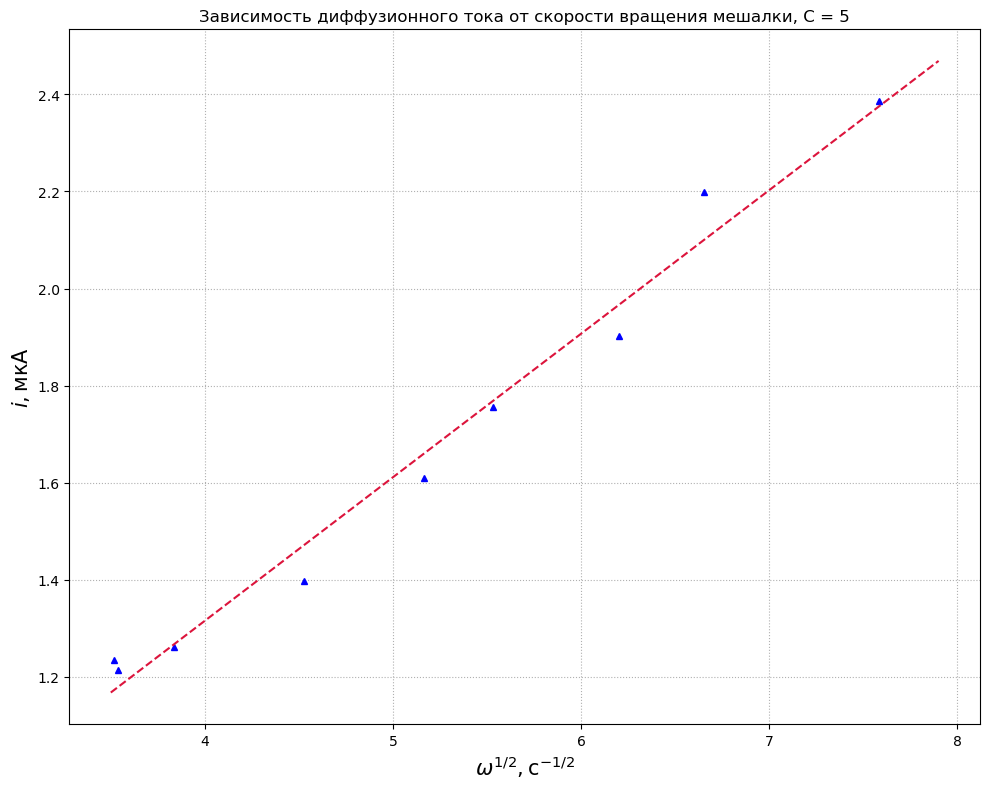

In [178]:
fig, ax = plt.subplots(figsize=(10, 8), layout="tight")
ax.plot(np.sqrt(omega), np.array(i_lim), '^', markersize=5, lw=0.01, color="b")
ax.plot([3.5, 7.9], linear(np.array([3.5, 7.9]), *args), linestyle="--", alpha=1, color="crimson")
plt.xlabel(r'$\omega^{1/2}, \text{c}^{-1/2}$', size=15), plt.ylabel(r'$i, \text{мкА}$', size=15)
plt.title("Зависимость диффузионного тока от скорости вращения мешалки, С = 5")
# plt.xlim(0, 0.3)
# plt.ylim(0, 1.4)
ax.grid(ls=':')

In [2]:
omega

NameError: name 'omega' is not defined